# Adjoint Solver for Spring-Slider Rate-and-State Friction

Extends the existing `springslider.ipynb` forward solver with an adjoint-based gradient computation.

**Setup:** Velocity-weakening friction (`a < b`), adaptive-step RK.

**State evolution:** Slip law — matches the existing forward solver exactly.

**Force balance convention:**
$$\tau(V,\psi) + \eta V + k u = \tau_L(t)$$

**Objective function (smoothed-slip misfit):**
$$J = \frac{1}{2}\int_0^T \left(Su - Su_{\rm obs}\right)^2 dt$$

where $S$ is a temporal Gaussian smoothing operator (row-normalised) and $u$ is the cumulative slip.

**Adjoint system** ($p = u^\dagger$, $r = \psi^\dagger$, BCs $p(T)=r(T)=0$)**:**

The system is a DAE. The Lagrangian introduces multipliers $p$, $r$ for the two ODEs and $\lambda$ for the algebraic force-balance constraint. Stationarity gives:

$$\delta u:\quad \dot{p} = k\lambda + \bigl[S^\top(Su - Su_{\rm obs})\bigr](t)$$
$$\delta\psi:\quad \dot{r} = \tau_\psi\,\lambda - G_\psi\,r$$
$$\delta V:\quad \lambda = \frac{p + G_V\,r}{\tau_V + \eta} \quad \text{(algebraic — no ODE)}$$

The adjoint solver integrates the $p,r$ ODEs **forwards in reversed time** $\tau = T - t$ and then re-inverts $\tau$ at the end.

**Gradient:**
$$\frac{dJ}{da} = \int_0^T \left[\lambda\,\frac{\partial\tau}{\partial a} - r\,\frac{\partial G}{\partial a}\right]dt$$

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
import scipy.sparse

## Physics: Friction Law and Jacobians

**Regularised RS friction (slip-law form used in original code):**
$$\tau(V,\psi) = N a\,\sinh^{-1}\!\left(\frac{V}{2V_0}e^{\psi/a}\right)$$

**State evolution — slip law:**
$$G(V,\psi) = -\frac{V}{D_c}\left(\frac{\tau}{N} - f_{\rm ss}\right), \quad f_{\rm ss} = f_0 + (a-b)\ln(V/V_0)$$

Partial derivatives are derived analytically.

In [2]:
from friction_derivs import *

Physics functions defined.


## Parameters and Afterslip Initial Conditions

Velocity-strengthening (`a > b`) with a coseismic stress step $\Delta\tau$ at $t=0$.

In [3]:
# ------------------------------------------------------------------
# Parameters
# ------------------------------------------------------------------
M = {}
M['f0']  = 0.6
M['V0']  = 1e-6      # m/s reference velocity
M['a']   = 0.010     # direct effect  (a > b → velocity strengthening)
M['b']   = 0.015     # state evolution
M['dc']  = 1e-4      # m critical slip distance
M['N']   = 50.0      # MPa effective normal stress
M['eta'] = 2.7 * 3.5 / 2.0   # MPa·s/m radiation damping
# M['k']   = 2e4       # MPa/m spring stiffness
k_crit = M['N'] * (M['b'] - M['a']) / M['dc']
M['k'] = 0.9 * k_crit

V_bg      = 1e-9     # m/s background / plate sliding rate
M['V_bg'] = V_bg

# ------------------------------------------------------------------
# Steady-state at V_bg
# ------------------------------------------------------------------
fss_bg = fss_fn(V_bg, M)
psi_ss = M['a'] * np.log(2.0 * M['V0'] / V_bg * np.sinh(fss_bg / M['a']))
tau_ss = M['N'] * fss_bg

# ------------------------------------------------------------------
# Initial conditions — V_init is the PRIMARY control parameter.
# tau0 is DERIVED from the force balance at t=0 (u=0):
#   tau(V_init, psi_init) + eta*V_init = tau0
# This ensures the forward solver starts at exactly V_init.
# ------------------------------------------------------------------
V_init   = 1.0e-12      # m/s  post-earthquake initial slip rate
psi_init = psi_ss    # pre-earthquake steady state at V_bg
u_init   = 0.0

M['tau0'] = tau_fn(V_init, psi_init, M) + M['eta'] * V_init
Delta_tau = M['tau0'] - tau_ss   # implied coseismic stress step (diagnostic)

# Characteristic afterslip time  T_c ~ N*a / (k * V_init)
T_c = M['N'] * M['a'] / (M['k'] * V_init)

print(f"a={M['a']}, b={M['b']}  →  velocity {'strengthening' if M['a']>M['b'] else 'weakening'}")
print(f"V_bg   = {V_bg:.2e} m/s,   V_init = {V_init:.2e} m/s  (ratio {V_init/V_bg:.1f}×)")
print(f"psi_ss = {psi_ss:.4f}")
print(f"tau_ss = {tau_ss:.4f} MPa")
print(f"tau0   = {M['tau0']:.4f} MPa  (Delta_tau = {Delta_tau:.4f} MPa)")
print(f"T_c    = {T_c:.3e} s  ({T_c/86400:.1f} days)")
print(f"k      = {M['k']:.2e} MPa/m,   k_crit = {k_crit:.2e} MPa/m  (k/k_crit = {M['k']/k_crit:.2f})")

a=0.01, b=0.015  →  velocity weakening
V_bg   = 1.00e-09 m/s,   V_init = 1.00e-12 m/s  (ratio 0.0×)
psi_ss = 0.7036
tau_ss = 31.7269 MPa
tau0   = 28.2731 MPa  (Delta_tau = -3.4539 MPa)
T_c    = 2.222e+08 s  (2572.0 days)
k      = 2.25e+03 MPa/m,   k_crit = 2.50e+03 MPa/m  (k/k_crit = 0.90)


## Adaptive Forward Solver

Uses a 3-stage embedded RK method (2nd/3rd-order pair) for automatic step-size control,
matching the MATLAB reference implementation.

**Method:** Three stages per trial step; accept if $\|[\Delta u,\,\Delta\psi]\|_2 < \text{tol}$;
adjust $\Delta t \leftarrow \sigma\,\Delta t\,(\text{tol}/e)^{1/3}$ where $\sigma=0.9$ is a safety factor.


In [4]:
from adapt_fwd_solve import *
# --- Run adaptive forward solve ---
T = 1e7    # s
print(f"Running adaptive forward solve: T={T:.1e} s ...")
fwd = forward_solve_adaptive(M, T, u_init, psi_init, V_init=V_init)
print(f"Done.  Steps={len(fwd['t'])-1},  V(0)={fwd['V'][0]:.6e},  V(T)={fwd['V'][-1]:.3e} m/s")
print(f"tau_L: {fwd['tau_L'][0]:.4f} → {fwd['tau_L'][-1]:.4f} MPa")


Running adaptive forward solve: T=1.0e+07 s ...
Done.  Steps=714,  V(0)=1.000000e-12,  V(T)=6.325e-11 m/s
tau_L: 28.2731 → 50.7731 MPa


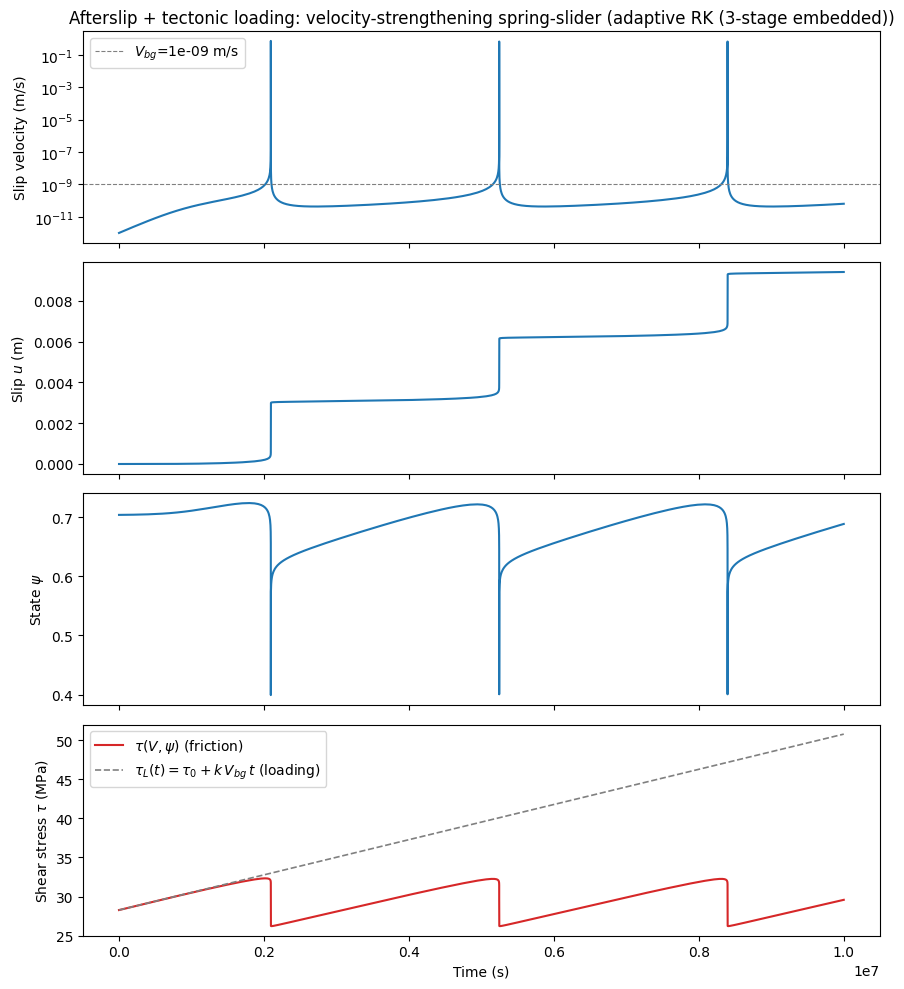

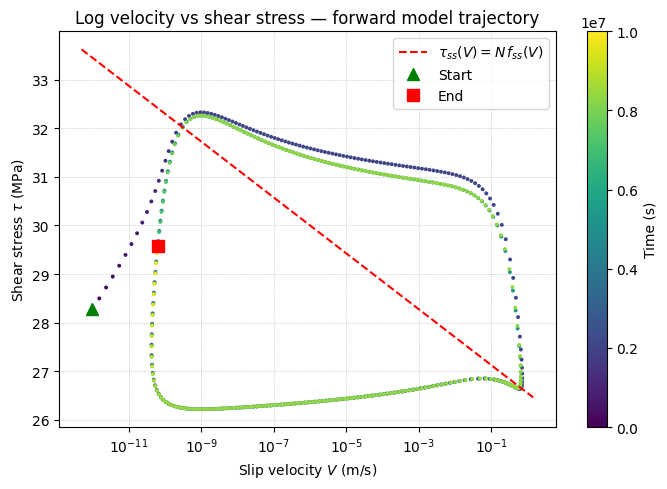

tau range: 26.2177 – 32.3301 MPa
V   range: 1.000e-12 – 7.087e-01 m/s


In [5]:
# ------------------------------------------------------------------
# Plot 1: Forward solution
# ------------------------------------------------------------------
tau_fwd = np.array([tau_fn(v, p, M) for v, p in zip(fwd['V'], fwd['psi'])])

fig, axes = plt.subplots(4, 1, figsize=(9, 10), sharex=True)

axes[0].plot(fwd['t'], fwd['V'])
axes[0].axhline(V_bg, color='gray', ls='--', lw=0.8, label=f'$V_{{bg}}$={V_bg:.0e} m/s')
axes[0].set_ylabel('Slip velocity (m/s)')
axes[0].set_yscale('log')
axes[0].set_title('Afterslip + tectonic loading: velocity-strengthening spring-slider (adaptive RK (3-stage embedded))')
axes[0].legend()

axes[1].plot(fwd['t'], fwd['u'])
axes[1].set_ylabel('Slip $u$ (m)')

axes[2].plot(fwd['t'], fwd['psi'])
axes[2].set_ylabel('State $\\psi$')

axes[3].plot(fwd['t'], tau_fwd, color='C3', label=r'$\tau(V,\psi)$ (friction)')
axes[3].plot(fwd['t'], fwd['tau_L'], color='gray', ls='--', lw=1.2,
             label=r'$\tau_L(t) = \tau_0 + k\,V_{bg}\,t$ (loading)')
axes[3].set_ylabel('Shear stress $\\tau$ (MPa)')
axes[3].set_xlabel('Time (s)')
axes[3].legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------------
# Plot 1c: Log velocity vs shear stress (phase portrait)
# ------------------------------------------------------------------
V_min = fwd['V'].min() * 0.5
V_max = fwd['V'].max() * 2.0
V_ss  = np.geomspace(V_min, V_max, 300)
tau_ss_line = M['N'] * fss_fn(V_ss, M)

fig3, ax3 = plt.subplots(figsize=(7, 5))
sc = ax3.scatter(fwd['V'], tau_fwd, c=fwd['t'], cmap='viridis',
                 s=8, lw=0, zorder=3)
ax3.plot(V_ss, tau_ss_line, 'r--', lw=1.5, zorder=4,
         label=r'$\tau_{ss}(V) = N\,f_{ss}(V)$')
ax3.set_xscale('log')
ax3.set_ylabel('Shear stress $\\tau$ (MPa)')
ax3.set_xlabel('Slip velocity $V$ (m/s)')
ax3.set_title('Log velocity vs shear stress — forward model trajectory')
cbar = fig3.colorbar(sc, ax=ax3)
cbar.set_label('Time (s)')
ax3.plot(fwd['V'][0],  tau_fwd[0],  'g^', ms=8, zorder=5, label='Start')
ax3.plot(fwd['V'][-1], tau_fwd[-1], 'rs', ms=8, zorder=5, label='End')
ax3.legend()
ax3.grid(True, ls=':', lw=0.5, which='both')
plt.tight_layout()
plt.show()

print(f"tau range: {tau_fwd.min():.4f} – {tau_fwd.max():.4f} MPa")
print(f"V   range: {fwd['V'].min():.3e} – {fwd['V'].max():.3e} m/s")

In [6]:
# Smoothing length scale — 5% of the total simulation duration
sigma_smooth = 0.1 * T
print(f"Smoothing σ = {sigma_smooth:.2e} s  ({sigma_smooth / 86400:.0f} days)")

Smoothing σ = 1.00e+06 s  (12 days)


## Adjoint Solver — Same Embedded RK with Linear Interpolation Within Step

We integrate the adjoint **forwards in reversed time** $\tau = T - t$ using the **same 3-stage embedded RK scheme** as the forward solver, stepping through the stored forward time grid in reverse order.

**Forward-state interpolation within each step:**  
The forward Jacobian coefficients $(\tau_V, \tau_\psi, G_V, G_\psi)$ and the smoothed misfit source $\mathrm{sm}$ are only stored at the grid nodes.  Within a step of size $\Delta\tau$ we linearly interpolate at fractional positions $\alpha \in \{0, \tfrac{1}{2}, 1\}$:
$$q(\alpha) = (1-\alpha)\,q_j + \alpha\,q_{j+1}$$

**RK stages** (adjoint RHS at reversed-time step $j\!\to\!j\!+\!1$, $\Delta\tau = t_j^{\rm rev} - t_{j+1}^{\rm rev} > 0$):
$$\mathbf{f}(p, r;\,\alpha) = \begin{pmatrix}
  -k\,\lambda - \mathrm{sm}(\alpha)\\
  -\tau_\psi(\alpha)\,\lambda + G_\psi(\alpha)\,r
\end{pmatrix}, \quad \lambda = \frac{p + G_V(\alpha)\,r}{\tau_V(\alpha)+\eta}$$

$$\mathbf{k}_1 = \mathbf{f}(y_j;\,\alpha{=}0), \quad
  \mathbf{k}_2 = \mathbf{f}\!\left(y_j+\tfrac{\Delta\tau}{2}\mathbf{k}_1;\,\alpha{=}\tfrac{1}{2}\right), \quad
  \mathbf{k}_3 = \mathbf{f}\!\left(y_j+\Delta\tau(-\mathbf{k}_1+2\mathbf{k}_2);\,\alpha{=}1\right)$$

**3rd-order update** (same weights as the forward solver):
$$y_{j+1} = y_j + \frac{\Delta\tau}{6}\!\left(\mathbf{k}_1 + 4\mathbf{k}_2 + \mathbf{k}_3\right)$$

At the end the arrays are reversed to recover $(p(t), r(t), \lambda(t))$ in original time order.

In [7]:
from adjoint_solve import *

print("Adjoint solver (3-stage embedded RK with linear forward-state interpolation) defined.")

Adjoint solver (3-stage embedded RK with linear forward-state interpolation) defined.


## Objective Function and Gradient

In [8]:
from compute_obj import *

# ------------------------------------------------------------------
# Generate synthetic observations at TRUE parameters
# ------------------------------------------------------------------
M_true = dict(M)
print("Generating synthetic u_obs with true a =", M_true['a'])
fwd_true  = forward_solve_adaptive(M_true, T, u_init, psi_init, V_init=V_init)
t_obs_arr = fwd_true['t']
u_obs     = fwd_true['u'].copy()
print(f"u_obs: u(0)={u_obs[0]:.4e} m,  u(T)={u_obs[-1]:.4e} m  ({len(t_obs_arr)} pts)")

J_true = compute_J(fwd_true, t_obs_arr, u_obs, sigma_smooth)
print(f"J at true parameters: {J_true:.2e}  (should be ~0)")

Generating synthetic u_obs with true a = 0.01
u_obs: u(0)=0.0000e+00 m,  u(T)=9.4188e-03 m  (715 pts)
J at true parameters: 0.00e+00  (should be ~0)


## Gradient Validation: Forward-Euler Adjoint vs Finite Differences

Before running the full adaptive-timestep gradient check, we first validate the adjoint equations on a **short time window** using a simple **Forward Euler** solver.

**Why FE first?**  Forward Euler is easy to reason about and very cheap.  
If the continuous adjoint equations are correct, the FE-adjoint gradient must agree with the FD gradient computed from FE forward solves (to within O(dt) discretisation error).  
We also overlay the FE and adaptive forward/adjoint solutions to verify they agree physically.

**Test setup:**
- Window: first characteristic timescale $T_c = N a/(k V_0)$  
- FE timestep: $T_c / 1000$ (well within the stability limit)  
- FD perturbation: centred difference, $\delta a = 10^{-5} a$

Test window : T_test  = 2.000e+06 s  (23.1 days = T_c)
FE timestep : dt      = 2.000e+02 s  =>  10000 steps
Smoothing σ : 2.000e+05 s

[1/6] FE forward solve  (a = 0.01100) ...
      10000 steps  |  V(T)=1.1145e-09 m/s  |  u(T)=1.4548e-03 m
[2/6] Adaptive RK forward solve ...
      9647 steps  |  V(T)=1.2513e-09 m/s  |  u(T)=1.3818e-03 m
[3/6] FE adjoint solve ...
(10001,) (24,) (24,)
[4/6] Adaptive adjoint solve ...
(9648,) (24,) (24,)
[5/6] FD gradient via FE  (da = 1.10e-07) ...
[6/6] FD gradient via adaptive RK  (da = 1.10e-07) ...

----------------------------------------------------------------------------
Quantity                                    FE forward    Adaptive fwd
----------------------------------------------------------------------------
J                                         4.647704e-03    6.876990e-02
dJ/da  (adjoint)                         -1.473165e+01    7.807222e+01
dJ/da  (FD)                               1.482131e+01   -1.538086e+02
relative error vs F

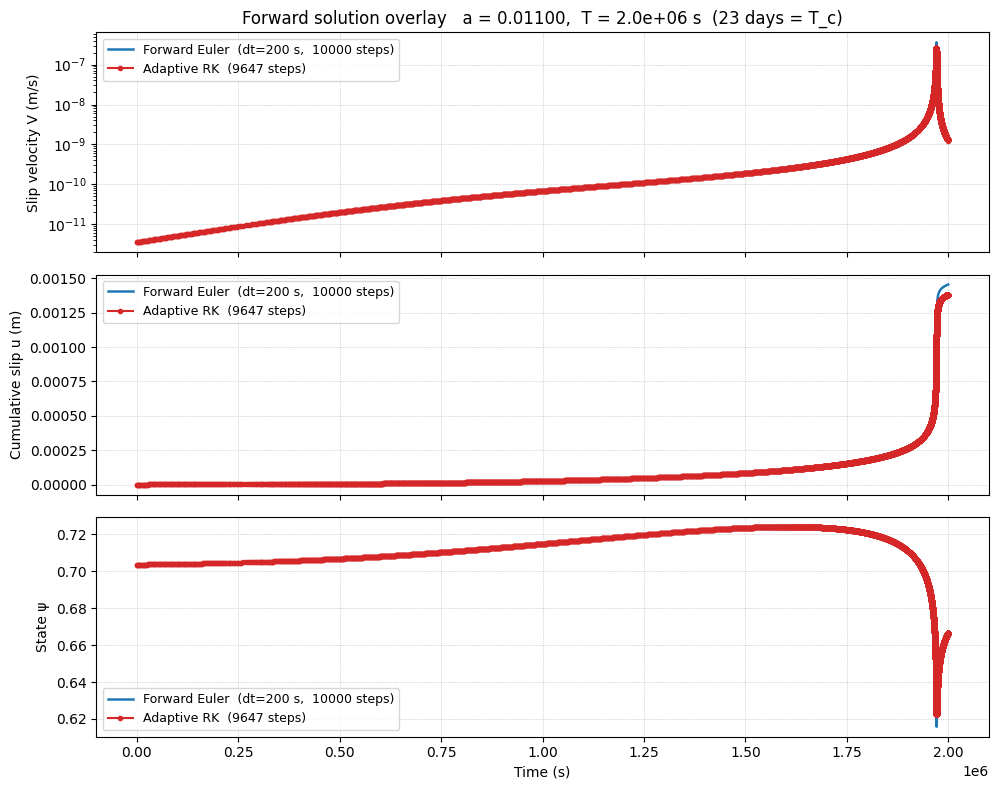

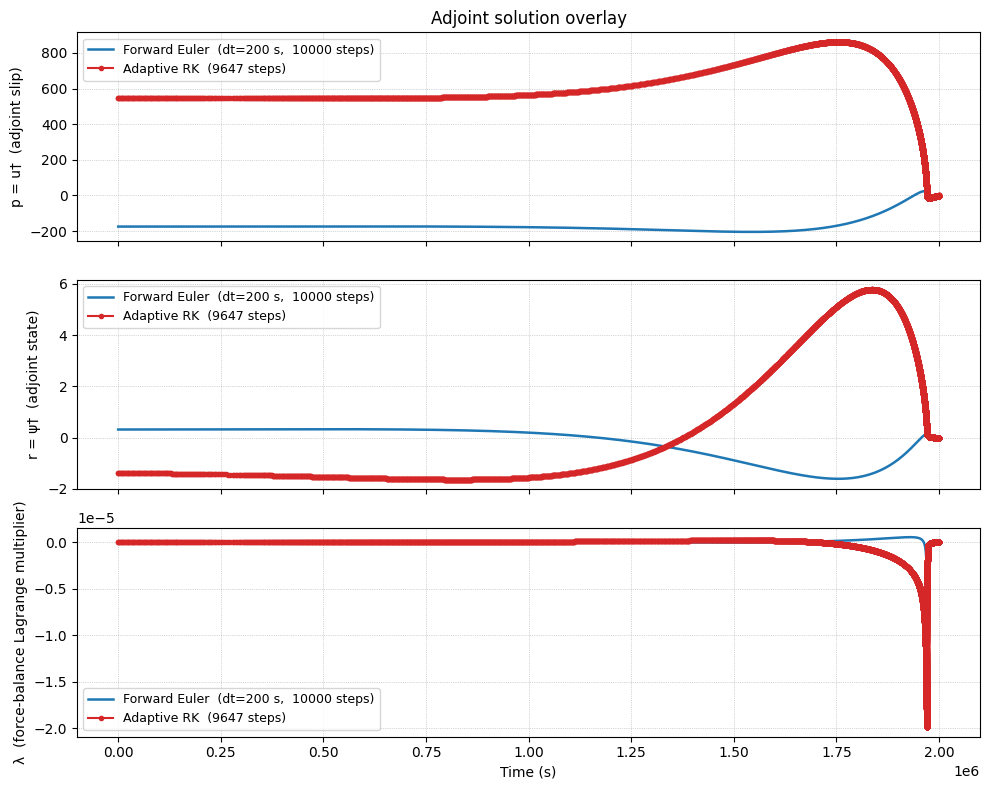

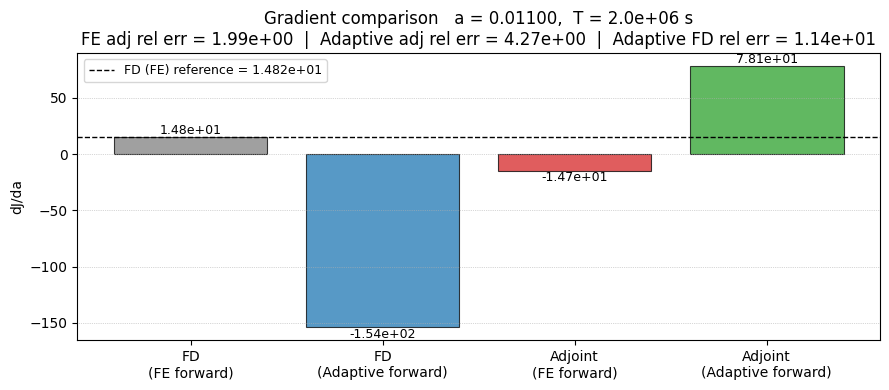

In [30]:
# ======================================================================
# VALIDATION: FE adjoint gradient vs finite-difference gradient
#             + overlay of FE vs adaptive solutions
# ======================================================================

# ------------------------------------------------------------------
# Forward Euler solver (same dict structure as forward_solve_adaptive)
# ------------------------------------------------------------------
def forward_solve_euler(M, T, u0, psi0, dt):
    """
    Fixed-step Forward Euler forward solver.
    Returns the same dict structure as forward_solve_adaptive so it
    plugs directly into adjoint_solve / compute_J / compute_grad_a.
    """
    tau_L_fn = lambda t: M['tau0'] + M['k'] * M['V_bg'] * t

    def _jac(V, psi):
        return (tau_V_fn(V, psi, M), tau_psi_fn(V, psi, M),
                G_V_fn(V, psi, M),   G_psi_fn(V, psi, M),
                dtau_da_fn(V, psi, M), dG_da_fn(V, psi, M))

    t = 0.0; u = u0; psi = psi0
    V0 = solve_V_algebraic(u0, psi0, M, tau_L_fn(0.0))
    j0 = _jac(V0, psi0)

    t_arr    = [0.0];     u_arr    = [u0];    psi_arr  = [psi0]
    V_arr    = [V0];      tauL_arr = [tau_L_fn(0.0)]
    tV_arr   = [j0[0]];   tP_arr   = [j0[1]]; GV_arr   = [j0[2]]
    GP_arr   = [j0[3]];   da_arr   = [j0[4]]; dGa_arr  = [j0[5]]

    while t < T - 1e-12 * T:
        dt_step = min(dt, T - t)
        V   = V_arr[-1]
        G   = G_fn(V, psi, M)

        u_new   = u   + dt_step * V
        psi_new = psi + dt_step * G
        t_new   = t   + dt_step

        tL    = tau_L_fn(t_new)
        V_new = solve_V_algebraic(u_new, psi_new, M, tL)
        j     = _jac(V_new, psi_new)

        t_arr.append(t_new);    u_arr.append(u_new);    psi_arr.append(psi_new)
        V_arr.append(V_new);    tauL_arr.append(tL)
        tV_arr.append(j[0]);    tP_arr.append(j[1]);    GV_arr.append(j[2])
        GP_arr.append(j[3]);    da_arr.append(j[4]);    dGa_arr.append(j[5])

        t, u, psi = t_new, u_new, psi_new

    return dict(
        t       = np.array(t_arr),
        u       = np.array(u_arr),
        psi     = np.array(psi_arr),
        V       = np.array(V_arr),
        tau_L   = np.array(tauL_arr),
        tau_V   = np.array(tV_arr),
        tau_psi = np.array(tP_arr),
        G_V     = np.array(GV_arr),
        G_psi   = np.array(GP_arr),
        dtau_da = np.array(da_arr),
        dG_da   = np.array(dGa_arr),
    )

# ------------------------------------------------------------------
# Test window: first characteristic timescale T_c
# FE stability limit:  dt < 1 / max|G_psi| ~ dc/(V * tau_psi/N)
#   At V_bg=1e-9, |G_psi| ~ 6e-6 s^-1  =>  dt_max ~ 1.7e5 s
#   We use T_c/1000 ~ 5e3 s  (safely stable)
# ------------------------------------------------------------------
T_test   = T_c * 0.9e-2
dt_euler = T_test / 10000.0
n_euler  = int(round(T_test / dt_euler))
print(f"Test window : T_test  = {T_test:.3e} s  ({T_test/86400:.1f} days = T_c)")
print(f"FE timestep : dt      = {dt_euler:.3e} s  =>  {n_euler} steps")

# 10 % perturbation in a (same as the existing gradient-check cell below)
M_fe      = dict(M_true)
M_fe['a'] = M_true['a'] * 1.1
da_fd     = M_fe['a'] * 1e-5          # central-difference perturbation

# Smoothing length for the short window
sigma_test = 0.1 * T_test
print(f"Smoothing σ : {sigma_test:.3e} s")

# Observations clipped to [0, T_test]
mask_obs   = fwd_true['t'] <= T_test + 1.0
t_obs_test = fwd_true['t'][mask_obs]
u_obs_test = fwd_true['u'][mask_obs]

# ------------------------------------------------------------------
# Step 1 & 2: forward solves
# ------------------------------------------------------------------
print(f"\n[1/6] FE forward solve  (a = {M_fe['a']:.5f}) ...")
fwd_fe = forward_solve_euler(M_fe, T_test, u_init, psi_init, dt_euler)
print(f"      {len(fwd_fe['t'])-1} steps  |  V(T)={fwd_fe['V'][-1]:.4e} m/s  |  u(T)={fwd_fe['u'][-1]:.4e} m")

print(f"[2/6] Adaptive RK forward solve ...")
fwd_ad = forward_solve_adaptive(M_fe, T_test, u_init, psi_init)
print(f"      {len(fwd_ad['t'])-1} steps  |  V(T)={fwd_ad['V'][-1]:.4e} m/s  |  u(T)={fwd_ad['u'][-1]:.4e} m")

J_fe = compute_J(fwd_fe, t_obs_test, u_obs_test, sigma_test)
J_ad = compute_J(fwd_ad, t_obs_test, u_obs_test, sigma_test)

# ------------------------------------------------------------------
# Step 3 & 4: adjoint solves
# ------------------------------------------------------------------
print(f"[3/6] FE adjoint solve ...")
adj_fe      = adjoint_solve(fwd_fe, t_obs_test, u_obs_test, M_fe, sigma_test)
grad_adj_fe = compute_grad_a(fwd_fe, adj_fe, M_fe)

print(f"[4/6] Adaptive adjoint solve ...")

# ---- Method A (original): adaptive adjoint, Jacobians from adaptive forward ----
adj_ad      = adjoint_solve(fwd_ad, t_obs_test, u_obs_test, M_fe, sigma_test)
grad_adj_ad = compute_grad_a(fwd_ad, adj_ad, M_fe)

# ---- Method B (new): adaptive time steps, Jacobians interpolated from FE forward ----
# adj_ad = adjoint_solve(fwd_ad, t_obs_test, u_obs_test,
 # M_fe, sigma_test, fwd_interp=fwd_fe)
# _fwd_ad_for_grad = dict(fwd_ad)
# _fwd_ad_for_grad['dtau_da'] = np.interp(fwd_ad['t'], fwd_fe['t'], fwd_fe['dtau_da'])
# _fwd_ad_for_grad['dG_da']   = np.interp(fwd_ad['t'], fwd_fe['t'], fwd_fe['dG_da'])
# grad_adj_ad = compute_grad_a(_fwd_ad_for_grad, adj_ad, M_fe)
# ----

# ------------------------------------------------------------------
# Step 5: FD gradient — FE forward solves
# ------------------------------------------------------------------
print(f"[5/6] FD gradient via FE  (da = {da_fd:.2e}) ...")
M_p = dict(M_fe); M_p['a'] = M_fe['a'] + da_fd
M_m = dict(M_fe); M_m['a'] = M_fe['a'] - da_fd
J_p = compute_J(forward_solve_euler(M_p, T_test, u_init, psi_init, dt_euler),
                t_obs_test, u_obs_test, sigma_test)
J_m = compute_J(forward_solve_euler(M_m, T_test, u_init, psi_init, dt_euler),
                t_obs_test, u_obs_test, sigma_test)
grad_fd_fe = (J_p - J_m) / (2.0 * da_fd)

# ------------------------------------------------------------------
# Step 6: FD gradient — adaptive forward solves
# ------------------------------------------------------------------
print(f"[6/6] FD gradient via adaptive RK  (da = {da_fd:.2e}) ...")
J_p_ad = compute_J(forward_solve_adaptive(M_p, T_test, u_init, psi_init),
                   t_obs_test, u_obs_test, sigma_test)
J_m_ad = compute_J(forward_solve_adaptive(M_m, T_test, u_init, psi_init),
                   t_obs_test, u_obs_test, sigma_test)
grad_fd_ad = (J_p_ad - J_m_ad) / (2.0 * da_fd)

# keep grad_fd pointing at the FE FD reference (used by downstream cells)
grad_fd = grad_fd_fe

# ------------------------------------------------------------------
# Summary table
# ------------------------------------------------------------------
rel_fe    = abs(grad_adj_fe - grad_fd_fe) / (abs(grad_fd_fe) + 1e-30)
rel_ad    = abs(grad_adj_ad - grad_fd_fe) / (abs(grad_fd_fe) + 1e-30)
rel_fd_ad = abs(grad_fd_ad  - grad_fd_fe) / (abs(grad_fd_fe) + 1e-30)

print(f"\n{'':->76}")
print(f"{'Quantity':<38}  {'FE forward':>14}  {'Adaptive fwd':>14}")
print(f"{'':->76}")
print(f"{'J':<38}  {J_fe:14.6e}  {J_ad:14.6e}")
print(f"{'dJ/da  (adjoint)':<38}  {grad_adj_fe:14.6e}  {grad_adj_ad:14.6e}")
print(f"{'dJ/da  (FD)':<38}  {grad_fd_fe:14.6e}  {grad_fd_ad:14.6e}")
print(f"{'relative error vs FD (FE)':<38}  {rel_fe:14.2e}  {rel_ad:14.2e}")
print(f"{'PASS / FAIL  (< 5 %)':<38}  {'PASS' if rel_fe < 0.05 else 'FAIL':>14}  "
      f"{'PASS' if rel_ad < 0.05 else 'FAIL':>14}")
print(f"{'FD (adaptive) vs FD (FE) rel err':<38}  {'—':>14}  {rel_fd_ad:14.2e}")
print(f"{'':->76}")

# ======================================================================
# Plot A — Forward solution overlay (V, u, psi)
# ======================================================================
kw_fe = dict(color='C0', lw=1.8,  label=f'Forward Euler  (dt={dt_euler:.0f} s,  {n_euler} steps)')
# kw_ad = dict(color='C3', lw=1.4,  ls='--', label=f'Adaptive RK  ({len(fwd_ad["t"])-1} steps)')
kw_ad = dict(color='C3', marker='.', label=f'Adaptive RK  ({len(fwd_ad["t"])-1} steps)')

fig_a, axs_a = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axs_a[0].semilogy(fwd_fe['t'], fwd_fe['V'], **kw_fe)
axs_a[0].semilogy(fwd_ad['t'], fwd_ad['V'], **kw_ad)
axs_a[0].set_ylabel('Slip velocity V (m/s)')
axs_a[0].set_title(f'Forward solution overlay   a = {M_fe["a"]:.5f},  '
                   f'T = {T_test:.1e} s  ({T_test/86400:.0f} days = T_c)')
axs_a[0].legend(fontsize=9); axs_a[0].grid(True, ls=':', lw=0.5)

axs_a[1].plot(fwd_fe['t'], fwd_fe['u'], **kw_fe)
axs_a[1].plot(fwd_ad['t'], fwd_ad['u'], **kw_ad)
axs_a[1].set_ylabel('Cumulative slip u (m)')
axs_a[1].legend(fontsize=9); axs_a[1].grid(True, ls=':', lw=0.5)

axs_a[2].plot(fwd_fe['t'], fwd_fe['psi'], **kw_fe)
axs_a[2].plot(fwd_ad['t'], fwd_ad['psi'], **kw_ad)
axs_a[2].set_ylabel('State ψ')
axs_a[2].set_xlabel('Time (s)')
axs_a[2].legend(fontsize=9); axs_a[2].grid(True, ls=':', lw=0.5)

plt.tight_layout()
plt.show()

# ======================================================================
# Plot B — Adjoint solution overlay (p, r, λ)
# ======================================================================
fig_b, axs_b = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axs_b[0].plot(adj_fe['t'], adj_fe['p'], **kw_fe)
axs_b[0].plot(adj_ad['t'], adj_ad['p'], **kw_ad)
axs_b[0].set_ylabel('p = u†  (adjoint slip)')
axs_b[0].set_title('Adjoint solution overlay')
axs_b[0].legend(fontsize=9); axs_b[0].grid(True, ls=':', lw=0.5)

axs_b[1].plot(adj_fe['t'], adj_fe['r'], **kw_fe)
axs_b[1].plot(adj_ad['t'], adj_ad['r'], **kw_ad)
axs_b[1].set_ylabel('r = ψ†  (adjoint state)')
axs_b[1].legend(fontsize=9); axs_b[1].grid(True, ls=':', lw=0.5)

axs_b[2].plot(adj_fe['t'], adj_fe['lam'], **kw_fe)
axs_b[2].plot(adj_ad['t'], adj_ad['lam'], **kw_ad)
axs_b[2].set_ylabel('λ  (force-balance Lagrange multiplier)')
axs_b[2].set_xlabel('Time (s)')
axs_b[2].legend(fontsize=9); axs_b[2].grid(True, ls=':', lw=0.5)

plt.tight_layout()
plt.show()

# ======================================================================
# Plot C — Gradient bar chart
# ======================================================================
fig_c, ax_c = plt.subplots(figsize=(9, 4))
labels_c = ['FD\n(FE forward)', 'FD\n(Adaptive forward)', 'Adjoint\n(FE forward)', 'Adjoint\n(Adaptive forward)']
vals_c   = [grad_fd_fe, grad_fd_ad, grad_adj_fe, grad_adj_ad]
colors_c = ['gray', 'C0', 'C3', 'C2']
bars_c   = ax_c.bar(labels_c, vals_c, color=colors_c, alpha=0.75, edgecolor='k', lw=0.8)
ax_c.axhline(grad_fd_fe, color='k', ls='--', lw=1.0, label=f'FD (FE) reference = {grad_fd_fe:.3e}')

for bar, v in zip(bars_c, vals_c):
    offset = 0.03 * abs(grad_fd_fe)
    va = 'bottom' if v >= 0 else 'top'
    y  = v + (offset if v >= 0 else -offset)
    ax_c.text(bar.get_x() + bar.get_width() / 2, y, f'{v:.2e}',
              ha='center', va=va, fontsize=9)

ax_c.set_ylabel('dJ/da')
ax_c.set_title(f'Gradient comparison   a = {M_fe["a"]:.5f},  T = {T_test:.1e} s\n'
               f'FE adj rel err = {rel_fe:.2e}  |  Adaptive adj rel err = {rel_ad:.2e}  |  '
               f'Adaptive FD rel err = {rel_fd_ad:.2e}')
ax_c.legend(fontsize=9)
ax_c.grid(True, ls=':', lw=0.5, axis='y')
plt.tight_layout()
plt.show()

Caching 44 forward solves  [a_true = 0.0100] ...
  [8/44]  a=0.00619
  [16/44]  a=0.00869
  [24/44]  a=0.01017
  [32/44]  a=0.01380
  [40/44]  a=0.02127
  [44/44]  a=0.02500


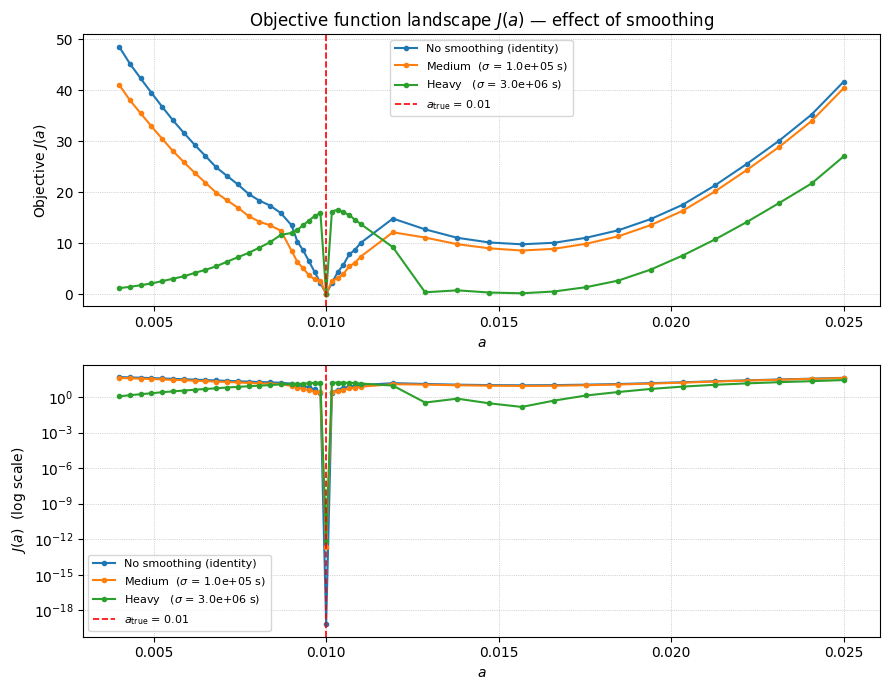


No smoothing (identity)                             min J = 6.440e-20  at a = 0.01000
Medium  ($\sigma$ = 1.0e+05 s)                      min J = 2.109e-13  at a = 0.01000
Heavy   ($\sigma$ = 3.0e+06 s)                      min J = 6.665e-13  at a = 0.01000


In [ ]:
# ------------------------------------------------------------------
# Objective function landscape: J(a) for three smoothing levels
# ------------------------------------------------------------------
a_true_val = M_true['a']

# Local Gaussian builder — bypasses the identity override in make_smoothing_matrix
def gaussian_S(t, sigma):
    """Row-normalised Gaussian smoothing kernel on an arbitrary time grid."""
    diff2 = (t[:, None] - t[None, :]) ** 2 / (2.0 * sigma ** 2)
    S = np.exp(-diff2)
    S /= S.sum(axis=1, keepdims=True)
    return S

def compute_J_S(fwd, t_obs, u_obs, S):
    """J = 0.5 * int_0^T (Su - Su_obs)^2 dt  with a pre-built S matrix."""
    u_obs_at_fwd = np.interp(fwd['t'], t_obs, u_obs)
    Su     = S @ fwd['u']
    Su_obs = S @ u_obs_at_fwd
    return 0.5 * np.trapz((Su - Su_obs) ** 2, fwd['t'])

# Three smoothing levels
sigma_medium = 0.01 * T    # ~58  days
sigma_heavy  = 0.3 * T

smoothing_cases = [
    ('No smoothing (identity)',                       None,         'C0'),
    (f'Medium  ($\\sigma$ = {sigma_medium:.1e} s)',   sigma_medium, 'C1'),
    (f'Heavy   ($\\sigma$ = {sigma_heavy:.1e} s)',    sigma_heavy,  'C2'),
]

# a values to scan — denser near the truth
a_scan = np.concatenate([
    np.linspace(0.4 * a_true_val, 0.9 * a_true_val, 16, endpoint=False),
    np.linspace(0.9 * a_true_val, 1.1 * a_true_val, 12, endpoint=False),
    np.linspace(1.1 * a_true_val, 2.5 * a_true_val, 16),
])

# --- Run all forward solves once (expensive), cache results ---
print(f"Caching {len(a_scan)} forward solves  [a_true = {a_true_val:.4f}] ...")
fwd_cache = []
for i, a_val in enumerate(a_scan):
    Mc = dict(M_true)
    Mc['a'] = a_val
    try:
        fwd_s = forward_solve_adaptive(Mc, T, u_init, psi_init)
    except Exception as e:
        fwd_s = None
        print(f"  a={a_val:.5f} failed: {e}")
    fwd_cache.append(fwd_s)
    if (i + 1) % 8 == 0 or i == len(a_scan) - 1:
        print(f"  [{i+1}/{len(a_scan)}]  a={a_val:.5f}")

# --- Evaluate J for each smoothing level using the cached forward solves ---
J_results = {}
for label, sigma, _ in smoothing_cases:
    J_arr = []
    for fwd_s in fwd_cache:
        if fwd_s is None:
            J_arr.append(np.nan)
            continue
        S = np.identity(len(fwd_s['t'])) if sigma is None else gaussian_S(fwd_s['t'], sigma)
        J_arr.append(compute_J_S(fwd_s, t_obs_arr, u_obs, S))
    J_results[label] = np.array(J_arr)

# ------------------------------------------------------------------
# Plot: one line per smoothing level, linear + log panels
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(9, 7))

for label, sigma, color in smoothing_cases:
    J_arr = J_results[label]
    J_pos = np.where(J_arr > 0, J_arr, np.nan)
    axes[0].plot(a_scan, J_arr,  'o-', ms=3, lw=1.5, color=color, label=label)
    axes[1].semilogy(a_scan, J_pos, 'o-', ms=3, lw=1.5, color=color, label=label)

for ax in axes:
    ax.axvline(a_true_val, color='red', ls='--', lw=1.2,
               label=f'$a_{{\\rm true}}$ = {a_true_val}')
    ax.legend(fontsize=8)
    ax.grid(True, ls=':', lw=0.5, which='both')
    ax.set_xlabel('$a$')

axes[0].set_ylabel('Objective $J(a)$')
axes[0].set_title('Objective function landscape $J(a)$ — effect of smoothing')
axes[1].set_ylabel('$J(a)$  (log scale)')

plt.tight_layout()
plt.savefig('Figures/J_landscape_a_smoothing.png', dpi=150, bbox_inches='tight')
plt.show()

print()
for label, sigma, _ in smoothing_cases:
    J_arr = J_results[label]
    imin  = np.nanargmin(J_arr)
    print(f"{label:50s}  min J = {J_arr[imin]:.3e}  at a = {a_scan[imin]:.5f}")

Using cached forward solve at a = 0.011000  (target: 0.011000)


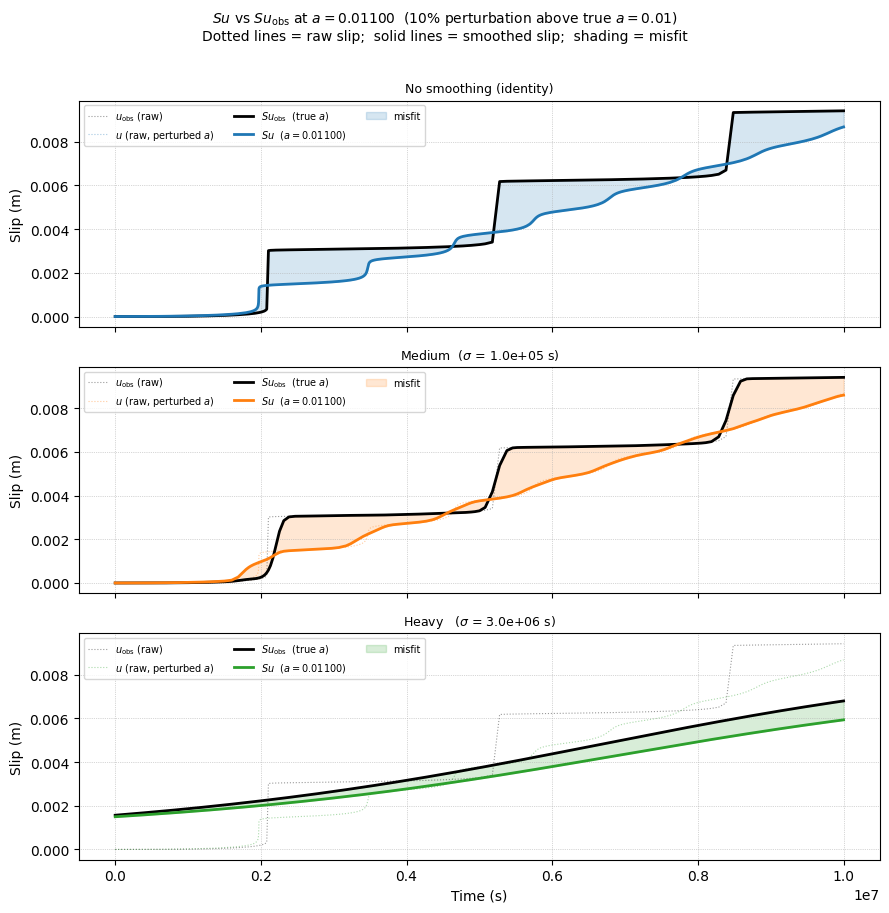

In [ ]:
# ------------------------------------------------------------------
# Plot: Su vs Su_obs at 10% perturbed a, for each smoothing level
# ------------------------------------------------------------------
# Find the cached forward solve closest to a = 1.1 * a_true
a_perturbed = 1.1 * a_true_val
idx_perturb = np.argmin(np.abs(a_scan - a_perturbed))
fwd_perturb = fwd_cache[idx_perturb]
a_used = a_scan[idx_perturb]
print(f"Using cached forward solve at a = {a_used:.6f}  (target: {a_perturbed:.6f})")

u_obs_interp = np.interp(fwd_perturb['t'], t_obs_arr, u_obs)

n_cases = len(smoothing_cases)
fig_cmp, axs_cmp = plt.subplots(n_cases, 1, figsize=(9, 3 * n_cases), sharex=True)
if n_cases == 1:
    axs_cmp = [axs_cmp]

for ax, (label, sigma, color) in zip(axs_cmp, smoothing_cases):
    if sigma is None:
        S_cmp = np.identity(len(fwd_perturb['t']))
    else:
        S_cmp = gaussian_S(fwd_perturb['t'], sigma)

    Su_cmp     = S_cmp @ fwd_perturb['u']
    Su_obs_cmp = S_cmp @ u_obs_interp

    # Raw slip (faint background reference)
    ax.plot(fwd_perturb['t'], u_obs_interp, color='black', lw=0.8, ls=':',
            alpha=0.4, label='$u_{\\rm obs}$ (raw)')
    ax.plot(fwd_perturb['t'], fwd_perturb['u'], color=color, lw=0.8, ls=':',
            alpha=0.4, label='$u$ (raw, perturbed $a$)')

    # Smoothed slip (main lines)
    ax.plot(fwd_perturb['t'], Su_obs_cmp, 'k-',     lw=2.0, label='$Su_{\\rm obs}$  (true $a$)')
    ax.plot(fwd_perturb['t'], Su_cmp,     color=color, lw=2.0, label=f'$Su$  ($a={a_used:.5f}$)')
    ax.fill_between(fwd_perturb['t'], Su_obs_cmp, Su_cmp,
                    alpha=0.18, color=color, label='misfit')

    ax.set_ylabel('Slip (m)')
    ax.set_title(label, fontsize=9)
    ax.legend(fontsize=7, ncol=3, loc='upper left')
    ax.grid(True, ls=':', lw=0.5)

axs_cmp[-1].set_xlabel('Time (s)')
fig_cmp.suptitle(
    f'$Su$ vs $Su_{{\\rm obs}}$ at $a = {a_used:.5f}$  '
    f'(10% perturbation above true $a = {a_true_val}$)\n'
    f'Dotted lines = raw slip;  solid lines = smoothed slip;  shading = misfit',
    fontsize=10, y=1.01
)
plt.tight_layout()
plt.savefig('Figures/u_uobs_comparison_smoothing.png', dpi=150, bbox_inches='tight')
plt.show()

## BFGS Inversion: Recover True $a$

Start at $a = 1.1\,a_{\rm true}$ and use **BFGS** (`scipy.optimize.minimize`) with the adjoint-derived gradient.

BFGS builds a quasi-Newton approximation to the inverse Hessian from successive gradient evaluations, giving super-linear convergence near the solution — typically far fewer iterations than steepest descent.

In [ ]:
from scipy.optimize import minimize

a_true_val = M_true['a']
a_init     = a_true_val * 1.1

J_hist    = []
a_hist    = [a_init]
grad_hist = []
u_hist    = []
t_hist    = []

def fun_and_grad(a_vec):
    """Returns (J, dJ/da) for use with scipy BFGS."""
    a_val = float(a_vec[0])
    Mc = dict(M_true)
    Mc['a'] = a_val
    fwd_it  = forward_solve_adaptive(Mc, T, u_init, psi_init)
    J_it    = compute_J(fwd_it, t_obs_arr, u_obs, sigma_smooth)
    adj_it  = adjoint_solve(fwd_it, t_obs_arr, u_obs, Mc, sigma_smooth)
    grad_it = compute_grad_a(fwd_it, adj_it, Mc)

    # Store history for plotting (called once per iteration)
    J_hist.append(J_it)
    grad_hist.append(grad_it)
    u_hist.append(fwd_it['u'].copy())
    t_hist.append(fwd_it['t'].copy())
    a_hist.append(a_val)

    it = len(J_hist)
    print(f"iter {it:3d}: J={J_it:.4e},  a={a_val:.6f},  "
          f"a_err={abs(a_val - a_true_val) / a_true_val * 100:.3f}%,  "
          f"dJ/da={grad_it:.4e}")

    return J_it, np.array([grad_it])

result = minimize(
    fun=fun_and_grad,
    x0=np.array([a_init]),
    method='BFGS',
    jac=True,           # fun returns (f, g) together
    options={
        'maxiter': 50,
        'gtol':    1e-8,
        'disp':    True,
    },
)

n_iter = len(J_hist)
print(f"\nBFGS finished: {result.message}")
print(f"Final a = {result.x[0]:.6f}  (true a = {a_true_val:.6f},  "
      f"error = {abs(result.x[0] - a_true_val) / a_true_val * 100:.4f}%)")
print(f"Total iterations: {n_iter}")

iter   1: J=5.3441e+04,  a=0.011000,  a_err=10.000%,  dJ/da=-2.9418e+57


ValueError: Force-balance RHS = -2.238e-09 <= 0; check tau_L and k*u.

In [ ]:
# ------------------------------------------------------------------
# Plot 4: BFGS convergence
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

iters = np.arange(1, n_iter + 1)

axes[0].semilogy(iters, J_hist, 'o-', ms=4)
axes[0].set_ylabel('Objective $J$')
axes[0].set_title('BFGS inversion: recovering $a$ from $u_{\\rm obs}$')
axes[0].grid(True, ls=':', lw=0.5)

axes[1].plot(iters, a_hist[:-1], 'o-', ms=4, label='$a$ (estimated)')
axes[1].axhline(a_true_val, color='k', ls='--', lw=1.0, label=f'$a_{{\\rm true}}$ = {a_true_val}')
axes[1].set_ylabel('$a$')
axes[1].set_xlabel('Iteration')
axes[1].legend()
axes[1].grid(True, ls=':', lw=0.5)

plt.tight_layout()
plt.show()

print(f"\nFinal a = {a_hist[-1]:.6f}  (true a = {a_true_val:.6f},  "
      f"error = {abs(a_hist[-1]-a_true_val)/a_true_val*100:.4f}%)")

Saving animation... this may take a moment.


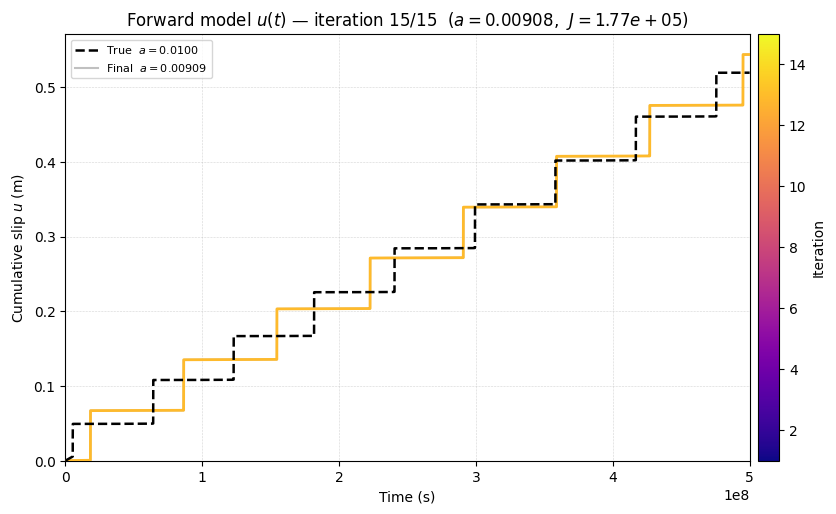

In [ ]:
# ------------------------------------------------------------------
# Plot 5 (animated): cycle through gradient descent iterations.
# ------------------------------------------------------------------
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig_anim, ax_anim = plt.subplots(figsize=(9, 5))

ax_anim.plot(t_obs_arr, u_obs, 'k--', lw=1.8,
             label=f'True  $a={a_true_val:.4f}$', zorder=5)

line_final, = ax_anim.plot(t_hist[-1], u_hist[-1], color='silver', lw=1.5,
                            ls='-', label=f'Final  $a={a_hist[n_iter]:.5f}$', zorder=2)

cmap_anim = plt.cm.plasma
line_curr, = ax_anim.plot([], [], lw=2.0, zorder=4)

sm = plt.cm.ScalarMappable(cmap=cmap_anim,
     norm=plt.Normalize(vmin=1, vmax=n_iter))
sm.set_array([])
cbar_anim = fig_anim.colorbar(sm, ax=ax_anim, pad=0.01)
cbar_anim.set_label('Iteration')

ax_anim.set_xlabel('Time (s)')
ax_anim.set_ylabel('Cumulative slip $u$ (m)')
ax_anim.grid(True, ls=':', lw=0.4, which='both')

all_u = np.concatenate(u_hist + [u_obs])
ax_anim.set_ylim(all_u.min() * 0.95, all_u.max() * 1.05)
ax_anim.set_xlim(t_obs_arr[0], t_obs_arr[-1])
ax_anim.legend(fontsize=8, loc='upper left')
title_obj = ax_anim.set_title('')

def _init():
    line_curr.set_data([], [])
    return line_curr, title_obj

def _update(frame):
    idx   = frame
    color = cmap_anim((idx) / max(n_iter - 1, 1) * 0.75 + 0.1)
    line_curr.set_data(t_hist[idx], u_hist[idx])
    line_curr.set_color(color)
    title_obj.set_text(
        f'Forward model $u(t)$ — iteration {idx+1}/{n_iter}  '
        f'($a={a_hist[idx]:.5f}$,  $J={J_hist[idx]:.2e}$)'
    )
    return line_curr, title_obj

anim = FuncAnimation(
    fig_anim, _update,
    frames=n_iter,
    init_func=_init,
    interval=600,
    blit=True,
    repeat=True,
)

plt.tight_layout()
writer = 'ffmpeg' # or 'avconv' if you prefer
print("Saving animation... this may take a moment.")
anim.save(
    'Figures/gradient_descent_evolution_adap_slip.gif', 
    writer=writer, 
    fps=3,        # Frames per second
    dpi=150,       # Image quality
    bitrate=1800   # Video bitrate (higher = better quality/larger file)
)

HTML(anim.to_jshtml())
